In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import torch
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from rna_vel_pred import datasets, utils

/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at4_ops16div__Tensor_mode4callERNS_6TensorERKS2_St8optionalIN3c1017basic_string_viewIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/reepoi/GitHub/velocityPrediction-new/.venv/lib/python3.10/site-packages/tor

In [3]:
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [4]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        # 'datasets=[{_target_:conf.datasets.H5adUMap,dataset:PANCREAS,umap_dimension:2}]',
        'datasets=[{_target_:conf.datasets.SimpleMotif}]',
        'model=First',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg)

Conf(root_dir='/home/reepoi/GitHub/velocityPrediction-new',
     out_dir='/home/reepoi/out/rna_vel_pred-new',
     data_subdir='/home/reepoi/out/rna_vel_pred-new/data_redesign',
     run_subdir='runs',
     prediction_filename='prediction.parquet',
     device='cuda',
     alt_id='mfrgxgyq',
     rng_seed=2376999025,
     fit=True,
     predict=False,
     is_optuna_sweep=False,
     id=6,
     datasets=[SimpleMotif(time_step_count_sparsify=10,
                           neighbor_count=10,
                           frac_train=0.7,
                           frac_val=0.2,
                           frac_test=0.1,
                           batch_size=10,
                           limit_batch_count_train=False,
                           batch_count_train=10,
                           reverse_velocities=False,
                           id=3,
                           measurement_count=4000,
                           initial_condition_noise_epsilon=0.05)],
     model=First(id=1,
   

In [5]:
splits = datasets.get_merged_dataset(cfg, cfg.data_dir, rng_seed=cfg.rng_seed)

Seed set to 2376999025
Seed set to 2376999025


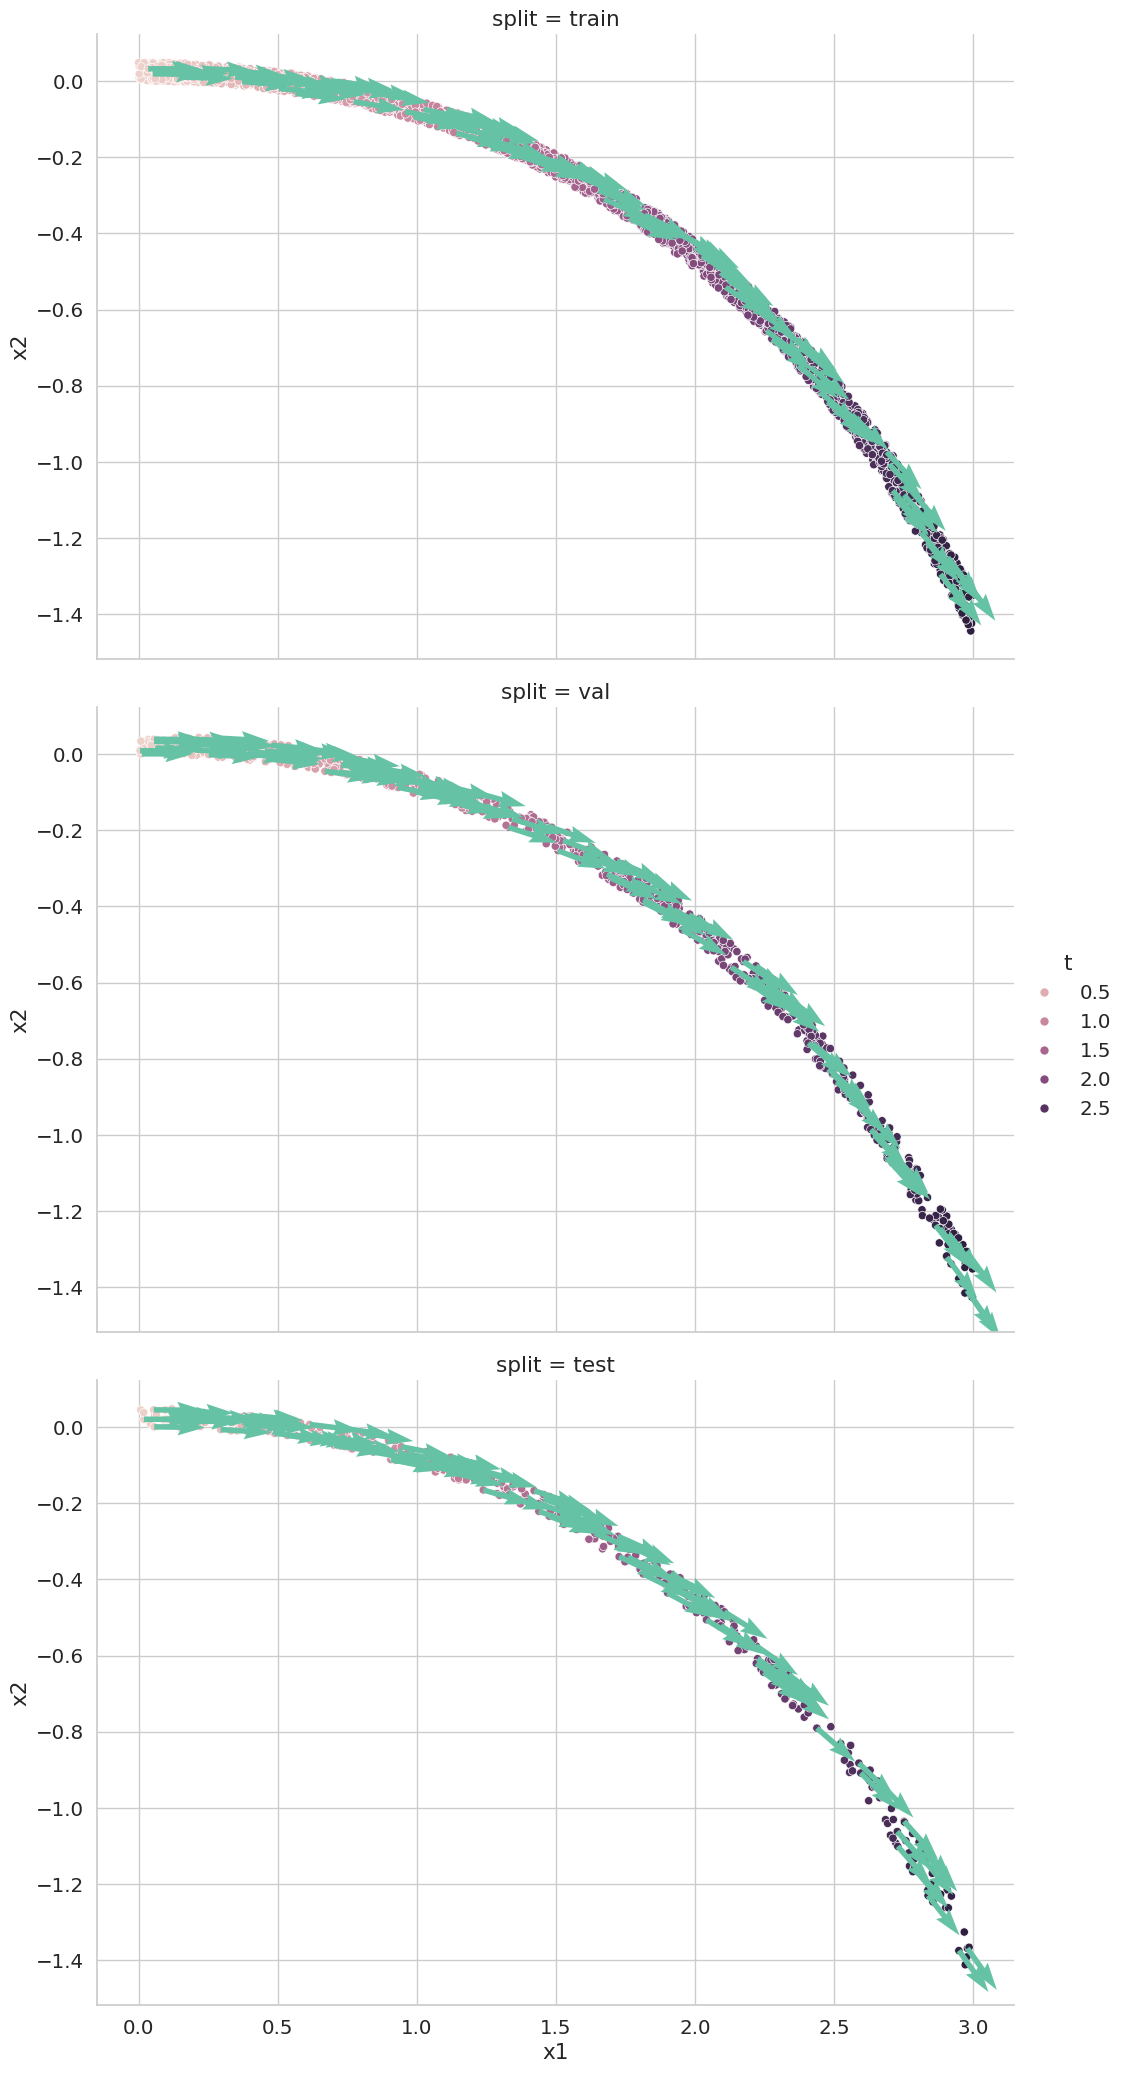

In [6]:
dfs = []
for split, dataset in splits.items():
    data = dataset.data
    df = pd.DataFrame(dict(
        measurement_id=data.poi_measurement_id,
        split=split,
        t=data.poi_t,
        **{f'x{i+1}': poi_pos_dim for i, poi_pos_dim in enumerate(data.poi_pos.T)},
        **{f'v{i+1}': poi_vel_dim for i, poi_vel_dim in enumerate(data.poi_vel.T)},
    ))
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='x1', y='x2',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    data = data.sample(100)
    ax.quiver(
        data['x1'], data['x2'], data['v1'], data['v2'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
    )

In [7]:
df.sort_values('t')

,measurement_id,split,t,x1,x2,v1,v2
2485,2054,train,0.000377,0.000377,0.048692,1.000000,-0.000072
277,1730,train,0.002158,0.002158,0.008825,1.000000,-0.000428
2454,2851,train,0.002161,0.002161,0.039960,1.000000,-0.000415
2432,76,train,0.002628,0.002628,0.019035,1.000000,-0.000516
1981,461,train,0.003346,0.003346,0.019599,1.000000,-0.000656
...,...,...,...,...,...,...,...
1123,1188,train,2.995114,2.995114,-1.423882,0.567213,-0.823571
1054,533,train,2.996472,2.996472,-1.407491,0.569649,-0.821888
2892,977,val,2.996556,2.996556,-1.426061,0.566682,-0.823936
210,1224,train,2.997251,2.997251,-1.350549,0.578762,-0.815497


tensor([2054])
Data(pos=[10, 2], poi_pos=[1, 2], poi_vel=[1, 2], poi_t=[1], poi_measurement_id=[1], vel=[10, 2], t=[10])
tensor([[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  0.9999,
          0.9999,  0.9999],
        [-0.0017, -0.0025, -0.0038, -0.0063, -0.0076, -0.0093, -0.0100, -0.0107,
         -0.0124, -0.0133]])
    split         t        x1        x2        v1        v2  is_poi
0   train  0.000377  0.000377  0.048692  1.000000 -0.000072    True
1   train  0.008559  0.008559  0.034116  0.999999 -0.001653   False
2   train  0.013323  0.013323  0.046570  0.999997 -0.002540   False
3   train  0.019260  0.019260  0.020414  0.999993 -0.003773   False
4   train  0.031527  0.031527  0.001267  0.999980 -0.006297   False
5   train  0.039630  0.039630  0.043220  0.999971 -0.007583   False
6   train  0.046590  0.046590  0.005060  0.999957 -0.009270   False
7   train  0.050751  0.050751  0.016603  0.999950 -0.009981   False
8   train  0.055899  0.055899  0.039025  0.99994

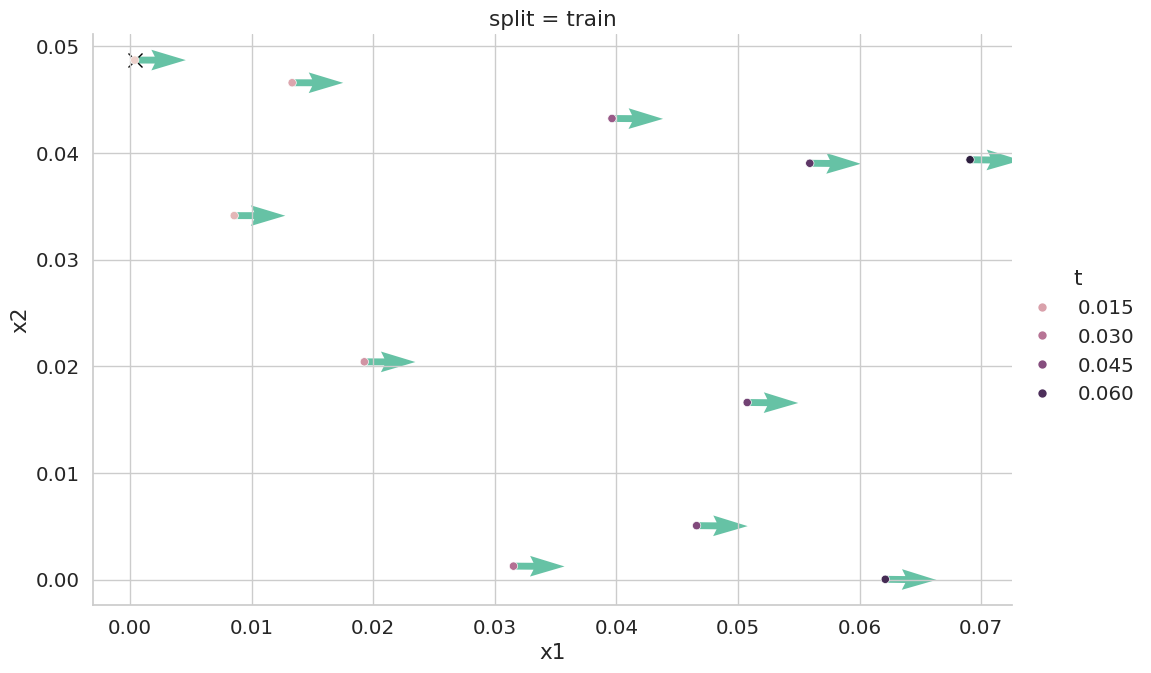

In [8]:
split = 'train'
data_idx = 2485
dataset = splits[split]
data = dataset[data_idx]
print(data.poi_measurement_id)
print(data)
print(data.vel.T)
df = pd.DataFrame(dict(
    split=split,
    t=torch.cat([data.t, data.poi_t]),
    **{f'x{i+1}': x for i, x in enumerate(torch.cat([data.pos, data.poi_pos]).T)},
    **{f'v{i+1}': v for i, v in enumerate(torch.cat([data.vel, data.poi_vel]).T)},
    is_poi=False,
))
df.loc[df.index[-1], 'is_poi'] = True
df = df.sort_values('t', ignore_index=True)
print(df)
plot = (
    sns.relplot(
        kind='scatter',
        data=df,
        row='split',
        hue='t',
        x='x1', y='x2',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    ax.quiver(
        data['x1'], data['x2'], data['v1'], data['v2'],
        # headwidth=1, headlength=15, headaxislength=2,
        color=None,
        zorder=0,
    )
    data_poi = data.query('is_poi')
    ax.plot(data_poi['x1'], data_poi['x2'], 'kx', markersize=10, zorder=0)